In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from iminuit import Minuit
from iminuit.cost import LeastSquares

#### Defining useful functions

In [ ]:
def read_csv(filename):
    """Read CSV from Waveforms"""
    dat = np.genfromtxt(filename, delimiter=",", skip_header=13, names=True)
    time = dat["Time_s"]
    voltage = dat["Channel_1_V"]
    return time, voltage


def find_start(time, voltage, show_plot=True):
    """Find timing of ball crossings"""
    threshold = 2.5  # Voltage threshold to detect crossing taken at aproximately the midpoint of the peaks
    crossings = np.where((voltage[:-1] < threshold) & (voltage[1:] >= threshold))[0]
    t_pass = time[crossings]
    t_pass_sigma = np.std(np.diff(t_pass)) / np.sqrt(len(t_pass) - 1)
    if show_plot:
        plt.plot(time, voltage, label="Waveform")
        plt.axhline(y=threshold, color="r", linestyle="--", label="Threshold")
        plt.scatter(t_pass, voltage[crossings], color="g", label="Crossings")
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.title("Waveform with Detected Crossings")
        plt.legend()
        plt.show()

    return t_pass, t_pass_sigma


def acc_func(t, s0, v0, a):
    """Position as a function of time with constant acceleration"""
    return s0 + v0 * t + 0.5 * a * t**2


def acc_fit(t_data, x_data, x_sigma):
    """Fit position data to constant acceleration model"""
    least_squares = LeastSquares(t_data, x_data, x_sigma, acc_func)

    # Create Minuit object with initial parameter guess
    m = Minuit(least_squares, a=1.0, v0=0, s0=0)  # Initial guess for acceleration

    # Perform the fit
    m.migrad()

    # Print results
    print(m.params)
    print(f"Best fit acceleration: {m.values['a']:.4f} ± {m.errors['a']:.4f}")

    # Optional: Check fit quality
    if m.valid:
        print(f"Chi-square / ndf: {m.fval:.2f} / {len(t_data) - 1}")
    return m.values, m.errors

### Loading gate positions and finding the acceleration from a fit

In [7]:
# Loading x-position data
excel_path = "C:\\Users\\jeppe\\AppStatLocal\\Project_Folder\\Project\\BallOnIncline\\Ball_data\\BallOnIncline_Group1_data.xlsx"
incline_length = pd.read_excel(
    excel_path, sheet_name="hældning_længder", skiprows=0, usecols="B:G"
)
mean_gateposition = []
sigma_gateposition = []
for i in range(5):
    length = np.mean(
        incline_length[f"mål_{i + 1}"].values - incline_length["åbning"].values
    )
    mean_gateposition.append(length)
    sigma = np.std(
        incline_length[f"mål_{i + 1}"].values - incline_length["åbning"].values, ddof=1
    )
    sigma_gateposition.append(sigma)
mean_gateposition = np.array(mean_gateposition) / 100  # Convert to meters
sigma_gateposition = np.array(sigma_gateposition) / 100  # Convert to meters
print("Mean gate positions:", np.array(mean_gateposition))
print("Sigma gate positions:", np.array(sigma_gateposition))


Mean gate positions: [0.15112 0.26478 0.41502 0.5634  0.7213 ]
Sigma gate positions: [0.00052154 0.00126174 0.00085264 0.00041833 0.00103682]


File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_1.csv, Crossing Times: [0.98128 1.1294  1.28494 1.41196 1.53072], Sigma: 0.007496522527145499
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ s0   │   0.157   │   0.018   │            │            │         │         │       │
│ 1 │ v0   │  -0.675   │   0.030   │            │            │         │         │       │
│ 2 │ a    │   1.364   │   0.025   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
Best fit acceleration: 1.3642 ± 0.0250
Chi-square / ndf: 0.44 / 4


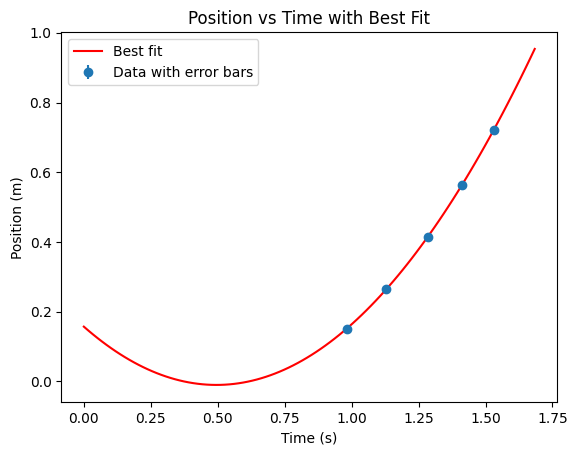

File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_2.csv, Crossing Times: [1.59348 1.74112 1.8963  2.02298 2.1416 ], Sigma: 0.007450021812048637
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ s0   │   0.82    │   0.04    │            │            │         │         │       │
│ 1 │ v0   │   -1.51   │   0.05    │            │            │         │         │       │
│ 2 │ a    │   1.367   │   0.025   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
Best fit acceleration: 1.3668 ± 0.0251
Chi-square / ndf: 0.56 / 4
File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_3.csv, Crossing T

In [8]:
# looping over time data and fitting to find acceleration
a_array = []
a_sigma_array = []
for i in range(10):
    filename = f"C:\\Users\\jeppe\\AppStatLocal\\Project_Folder\\Project\\BallOnIncline\\Ball_data\\BallIncline_{i + 1}.csv"
    time, voltage = read_csv(filename)
    t_pass, t_pass_sigma = find_start(time, voltage, show_plot=False)
    print(f"File: {filename}, Crossing Times: {t_pass}, Sigma: {t_pass_sigma}")
    params, errors = acc_fit(t_pass, mean_gateposition, sigma_gateposition)
    if i == 0:
        plt.errorbar(
            t_pass,
            mean_gateposition,
            yerr=sigma_gateposition,
            fmt="o",
            label="Data with error bars",
        )
        t_fit = np.linspace(0, np.max(t_pass) * 1.1, 100)
        x_fit = acc_func(t_fit, params["s0"], params["v0"], params["a"])
        plt.plot(t_fit, x_fit, label="Best fit", color="red")
        plt.xlabel("Time (s)")
        plt.ylabel("Position (m)")
        plt.title("Position vs Time with Best Fit")
        plt.legend()
        plt.show()
    a_array.append(params["a"])
    a_sigma_array.append(errors["a"])
a_array = np.array(a_array)
print("Accelerations from all trials:", a_array)

File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_rot_1.csv, Crossing Times: [1.28066 1.4291  1.5847  1.71194 1.83104], Sigma: 0.007462762139449448
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ s0   │   0.414   │   0.028   │            │            │         │         │       │
│ 1 │ v0   │   -1.07   │   0.04    │            │            │         │         │       │
│ 2 │ a    │   1.356   │   0.025   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
Best fit acceleration: 1.3563 ± 0.0249
Chi-square / ndf: 0.44 / 4


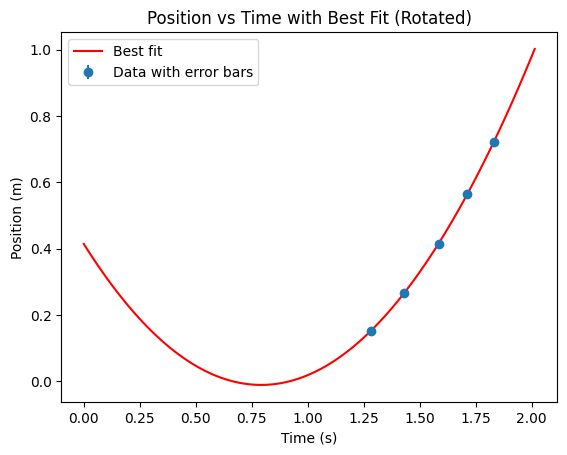

File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_rot_2.csv, Crossing Times: [1.16352 1.31168 1.46706 1.59396 1.71262], Sigma: 0.007501804366284152
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ s0   │   0.306   │   0.024   │            │            │         │         │       │
│ 1 │ v0   │  -0.929   │   0.035   │            │            │         │         │       │
│ 2 │ a    │   1.368   │   0.025   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
Best fit acceleration: 1.3681 ± 0.0251
Chi-square / ndf: 0.43 / 4
File: C:\Users\jeppe\AppStatLocal\Project_Folder\Project\BallOnIncline\Ball_data\BallIncline_rot_3.csv, Cr

In [ ]:
# Finding acceleration in rotated experiments
a_array_rot = []
a_sigma_array_rot = []
for i in range(10):
    filename_rot = f"C:\\Users\\jeppe\\AppStatLocal\\Project_Folder\\Project\\BallOnIncline\\Ball_data\\BallIncline_rot_{i + 1}.csv"
    time_rot, voltage_rot = read_csv(filename_rot)
    t_pass_rot, t_pass_sigma_rot = find_start(time_rot, voltage_rot, show_plot=False)
    print(
        f"File: {filename_rot}, Crossing Times: {t_pass_rot}, Sigma: {t_pass_sigma_rot}"
    )
    params, errors = acc_fit(t_pass_rot, mean_gateposition, sigma_gateposition)
    if i == 0:
        plt.errorbar(
            t_pass_rot,
            mean_gateposition,
            yerr=sigma_gateposition,
            fmt="o",
            label="Data with error bars",
        )
        t_fit = np.linspace(0, np.max(t_pass_rot) * 1.1, 100)
        x_fit = acc_func(t_fit, params["s0"], params["v0"], params["a"])
        plt.plot(t_fit, x_fit, label="Best fit", color="red")
        plt.xlabel("Time (s)")
        plt.ylabel("Position (m)")
        plt.title("Position vs Time with Best Fit (Rotated)")
        plt.legend()
        plt.show()
    a_array_rot.append(params["a"])
    a_sigma_array_rot.append(errors["a"])
a_array_rot = np.array(a_array_rot)
print("Accelerations from all trials (Rotated):", a_array_rot)

In [20]:
print(np.mean(a_array_rot))
print(np.std(a_array_rot, ddof=1))
print(np.mean(a_array))
print(np.std(a_array, ddof=1))

1.3694009269034333
0.005337574504152246
1.3658063105780829
0.0043700913414612885


In [ ]:
# Loading Goniometer angle data
gonio_angle_data = pd.read_excel(
    excel_path, sheet_name="goniometer_vinkelmål", skiprows=0, usecols="B:C"
)
gonio_angle_data_rot = pd.read_excel(
    excel_path, sheet_name="goniometer_vinkelmål", skiprows=0, usecols="D:E"
)
for i in range(len(gonio_angle_data)):
    print(
        f"Angle measurement {i + 1}: {gonio_angle_data['vinkel_original'][i]} degrees ± {gonio_angle_data['usikkerhed_original'][i]} degrees"
    )
angles_deg = gonio_angle_data["vinkel_original"].values
e_angles_rad = np.deg2rad(gonio_angle_data["usikkerhed_original"].values)
angles_rad = np.deg2rad(angles_deg)

angles_rot_deg = gonio_angle_data_rot["vinkel_roteret"].values
e_angles_rot_rad = np.deg2rad(gonio_angle_data_rot["usikkerhed_roteret"].values)
angles_rot_rad = np.deg2rad(angles_rot_deg)

Angle measurement 1: 14.05 degrees ± 0.05 degrees
Angle measurement 2: 14.1 degrees ± 0.05 degrees
Angle measurement 3: 14.1 degrees ± 0.05 degrees
Angle measurement 4: 14.1 degrees ± 0.05 degrees


In [ ]:
# Loading d_rail data, R_ball and calculating angle from length measurements
d_rail = np.array([6.125, 6.00, 6.05, 6.1]) / 1000  # from mm to m
e_d_rail = np.std(d_rail, ddof=1) / 1000

D_ball = 1 / 100  # from cm to m


In [ ]:
# Theta trigonometric

trig_data = pd.read_excel(
    excel_path, sheet_name="trigonometriske_målinger", skiprows=0, usecols="B:G"
)
højde = np.mean(trig_data["Højde"].values)
længde = np.mean(trig_data["Længde"].values)
hypo = np.mean(trig_data["Hypotenuse"].values)

print(f"Højde: {højde} m, Længde: {længde} m, Hypotenuse: {hypo} m")

theta_trig = np.arccos((længde**2 + hypo**2 - højde**2) / (2 * længde * hypo))

delta_theta_trig = ((np.mean(a_array) - np.mean(a_array_rot)) * np.sin(theta_trig)) / (
    (np.mean(a_array) + np.mean(a_array_rot)) * np.cos(theta_trig)
)
print(f"Trigonometric delta theta: {delta_theta_trig}")
print(f"Goniometer delta theta: {(np.mean(angles_rad) - np.mean(angles_rot_rad)) / 2}")


Højde: 22.2625 m, Længde: 89.775 m, Hypotenuse: 93.025 m
Trigonometric delta theta: -0.00032382001439170473
Gonoiometet delta theta: 0.002181661564992915


In [48]:
quick_g = (
    np.mean(a_array)
    / (np.sin(theta_trig + delta_theta_trig))
    * (1 + (2 / 5) * D_ball**2 / ((D_ball) ** 2 - (np.mean(d_rail)) ** 2))
)
print("Quick g calculation:", quick_g)


Quick g calculation: 9.335975062695558
